# <span style="color:red"> Final Project  </span>

# <span style="color:red"> Introduction:  </span>

<font size = "3">

This project explores how certain player skills in women's FIFA - specifically passing, dribbling, and shooting — have changed over time and how they relate to geographical origin and height. Using historical FIFA player rating datasets, which assign numerical skill scores to thousands of professional players each year, the analysis aims to answer three questions for players that attended all the FIFA match from 2016 to 2022: (1) How have passing, dribbling, and shooting ratings evolved over time? (2) Which countries tend to produce players with the highest ratings in these key skill categories? and (3) What is the relationship between a player’s height and their passing, dribbling, and shooting ratings? These questions are relevant because the FIFA data provides comprehensive, standardized views of player performance worldwide, which gives insights into how women's FIFA has changed over time, which technical skills are most related to height, and which nations might have the best training programs because of their players' high ratings.

The results of the analysis show trends in how player skill ratings have changed over time, reveal whether height is an advantage or disadvantage for certain skills, and identify which countries produce the best passers, shooters, and dribblers. The project is organized to first describe the datasets. Then, we look at each research question one-by-one in the same order detailed above. For each research question, we explain how datasets were merged and cleaned, and present the findings. At the end, we will discuss the findings for all our research questions. 

# <span style="color:red"> Data Description:  </span>

<font size = "3">

We are using the FIFA datasets from https://www.kaggle.com/datasets/joebeachcapital/fifa-players. Specifically, we are analyzing the female players datasets from 2016 to 2022. For each dataset, the rows represent a different player. The 2016 dataset has 248 observations, the 2017 dataset has 299 observations, the 2018 dataset has 317 observations, the 2019 dataset has 299 observations, the 2020 dataset has 345 observations, the 2021 dataset has 345 observations, and the 2022 dataset 291 observations.Our analysis will analyze the players that are common between each dataset. Each dataset contains information about each player's SoFIFA ID, name, overall player rating, projected potential overall player rating, age, physical attributes like weight and height, nationality, preferred foot to use when playing, reputation score, work rate and body type, technical skills their known for, and finally technical skill ratings for things like shooting, dribbling, and passing. 

<font size = "3">
Importing Necessary Libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

<font size = "3">
Importing Data:

In [2]:
data = {}
years = [16, 17, 18, 19, 20, 21, 22]


#make each year a seperate dataframe and add a year column
#make the datafram names df_16, df_17....

for y in years:
    df = pd.read_csv(f"2-FIFA/female_players_{y}.csv")
#f here means f-string, which allows to embed expressions inside string literals

    df['year'] = 2000 + y
    data[y] = df
    globals()[f"df_{y}"] = df

# <span style="color:red"> (1) How have shooting, dribbling, and passing ratings evolved over time? </span>

# <span style="color:red"> <font size = 5> Merging Procedure: </span>

<font size = 3>

To study trends in passing, dribbling, and shooting ratings over time for the same individuals, we performed successive inner joins starting with the 2016 dataset and sequentially merged each subsequent year on SoFifa ID. The number of players that were common between every dataset after merging is printed below. We then selected only the passing, dribbling, and shooting score columns for analysis. 

# <span style="color:red"> <font size = 5> Cleaning Procedure: </span>

<font size = 3>

 A mean column that averages each player's scores from 2016 to 2022 for each respective technical skill was calculated and added to the merged dataset. This column is not used for this research question, but is important for other research questions. To make the data easier to visualize graphically, we melted the dataframe into long form. In doing so, we created the new column "year," which is an int64 datatype. We removed the mean columns from the long dataframes because they were not important for this analysis. We used the .dropna() function to ensure there are no missing values for the passing, dribbling, and shooting skills columns we are interested in. Additionally, the passing, dribbling, and shooting columns were the correct datatype needed, float64, to visualize them graphically.

# <span style="color:red"> <font size = 5> Description of Main Columns: </span>

<font size = 3>

The main columns analyzed include sofifa_id and the passing, dribbling, and shooting score columns from 2016 to 2022. The sofifa_id column contains unique IDs for each soccer player. The passing, dribbling, and shooting score columns contain scores representing each player's ability with regards to each respective technical skill. 



In [3]:
#This merges all dataframes by sofifa_id
df_merged = df_16

#This for loop merges the data.
for y in [17, 18, 19, 20, 21, 22]:
    df_merged = df_merged.merge(data[y], 
                                on="sofifa_id", 
                                how="inner", 
                                suffixes=("", f"_{y}"))
    print(f"after df_16 merge with {y} , there are rows(number of players) left: {len(df_merged)}")


display(df_merged)

#This saves the merged dataframe to a csv file.
df_merged.to_csv("female_players_16_22_merged.csv", index=False)

#This gathers the column names in the merged dataframe.
df_merged.columns

after df_16 merge with 17 , there are rows(number of players) left: 205
after df_16 merge with 18 , there are rows(number of players) left: 165
after df_16 merge with 19 , there are rows(number of players) left: 96
after df_16 merge with 20 , there are rows(number of players) left: 81
after df_16 merge with 21 , there are rows(number of players) left: 73
after df_16 merge with 22 , there are rows(number of players) left: 64


,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,cb_22,rcb_22,rb_22,gk_22,player_face_url_22,club_logo_url_22,club_flag_url_22,nation_logo_url_22,nation_flag_url_22,year_22
0,226328,https://sofifa.com/player/226328/megan-rapinoe...,M. Rapinoe,Megan Anna Rapinoe,"LM, CM",90,90,NaN,NaN,29,...,60+3,60+3,66+3,21+3,https://cdn.sofifa.com/players/226/328/22_120.png,NaN,NaN,https://cdn.sofifa.com/teams/113009/60.png,https://cdn.sofifa.com/flags/us.png,2022
1,226359,https://sofifa.com/player/226359/christine-sin...,C. Sinclair,Christine Margaret Sinclair,"ST, LW, RW, CAM",88,88,NaN,NaN,32,...,54+3,54+3,58+3,18+3,https://cdn.sofifa.com/players/226/359/22_120.png,NaN,NaN,https://cdn.sofifa.com/teams/113000/60.png,https://cdn.sofifa.com/flags/ca.png,2022
2,226177,https://sofifa.com/player/226177/becky-sauerbr...,B. Sauerbrunn,Rebecca Elizabeth Sauerbrunn,CB,86,87,NaN,NaN,30,...,86+2,86+2,81+3,20+3,https://cdn.sofifa.com/players/226/177/22_120.png,NaN,NaN,https://cdn.sofifa.com/teams/113009/60.png,https://cdn.sofifa.com/flags/us.png,2022
3,226308,https://sofifa.com/player/226308/dzsenifer-mar...,D. Marozsán,Dzsenifer Marozsán,"CAM, CM",86,91,NaN,NaN,23,...,64+3,64+3,72+3,19+3,https://cdn.sofifa.com/players/226/308/22_120.png,NaN,NaN,https://cdn.sofifa.com/teams/113004/60.png,https://cdn.sofifa.com/flags/de.png,2022
4,226330,https://sofifa.com/player/226330/tobin-heath/1...,T. Heath,Tobin Powell Heath,"LM, CAM, RM",85,88,NaN,NaN,27,...,50+3,50+3,60+3,19+3,https://cdn.sofifa.com/players/226/330/22_120.png,NaN,NaN,https://cdn.sofifa.com/teams/113009/60.png,https://cdn.sofifa.com/flags/us.png,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,227466,https://sofifa.com/player/227466/kenti-robles/...,K. Robles,Vaitiare Kenti Robles Salas,RB,71,77,NaN,NaN,24,...,79+3,79+3,81+2,19+3,https://cdn.sofifa.com/players/227/466/22_120.png,NaN,NaN,https://cdn.sofifa.com/teams/113010/60.png,https://cdn.sofifa.com/flags/mx.png,2022
60,227775,https://sofifa.com/player/227775/amanda-samped...,Amanda Sampedro,Amanda Sampedro Bustos,CM,71,81,NaN,NaN,22,...,69+3,69+3,73+3,19+3,https://cdn.sofifa.com/players/227/775/22_120.png,NaN,NaN,https://cdn.sofifa.com/teams/113012/60.png,https://cdn.sofifa.com/flags/es.png,2022
61,227391,https://sofifa.com/player/227391/stephanie-lab...,S. Labbé,Stephanie Lynn Marie Labbé,GK,70,73,NaN,NaN,28,...,27+2,27+2,28+2,79+1,https://cdn.sofifa.com/players/227/391/22_120.png,NaN,NaN,https://cdn.sofifa.com/teams/113000/60.png,https://cdn.sofifa.com/flags/ca.png,2022
62,227776,https://sofifa.com/player/227776/sandra-panos-...,Sandra Paños,Sandra Paños García-Villamil,GK,69,77,NaN,NaN,22,...,28+2,28+2,28+2,80+2,https://cdn.sofifa.com/players/227/776/22_120.png,NaN,NaN,https://cdn.sofifa.com/teams/113012/60.png,https://cdn.sofifa.com/flags/es.png,2022


Index(['sofifa_id', 'player_url', 'short_name', 'long_name',
       'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur',
       'age',
       ...
       'cb_22', 'rcb_22', 'rb_22', 'gk_22', 'player_face_url_22',
       'club_logo_url_22', 'club_flag_url_22', 'nation_logo_url_22',
       'nation_flag_url_22', 'year_22'],
      dtype='object', length=771)

<font size = 3>
Get All the Passing Score Columns: 

In [4]:
#This specificies the year the data was gathered in by renaming the passing column to "passing_16".
df_merged = df_merged.rename(columns={"passing": "passing_16"})

#This gathers their passing skill for years 2016 to 2022.
passing_cols = [f"passing_{y}" for y in years]
print(passing_cols)

#This creates a new dataframe with only player sofifa_id and passing skill.
df_passing = df_merged[["sofifa_id"] + passing_cols]

#This drops na values from the new dataframe.
df_passing = df_passing.dropna()

#This calculates the mean passing skill for each observation.
df_passing["mean_passing"] = df_passing[passing_cols].mean(axis=1)


df_passing_sorted = df_passing.sort_values(by="mean_passing", ascending=False, inplace=False)
#This creates a new dataframe for the "mean_passing" column in descending order. 

display(df_passing_sorted)




['passing_16', 'passing_17', 'passing_18', 'passing_19', 'passing_20', 'passing_21', 'passing_22']


,sofifa_id,passing_16,passing_17,passing_18,passing_19,passing_20,passing_21,passing_22,mean_passing
0,226328,90.0,90.0,90.0,90.0,93.0,93.0,90.0,90.857143
3,226308,87.0,87.0,87.0,87.0,90.0,90.0,90.0,88.285714
4,226330,86.0,86.0,86.0,85.0,89.0,89.0,89.0,87.142857
1,226359,84.0,85.0,85.0,84.0,85.0,85.0,85.0,84.714286
9,227405,79.0,82.0,82.0,81.0,81.0,81.0,81.0,81.000000
7,226975,80.0,80.0,80.0,80.0,82.0,82.0,82.0,80.857143
49,227327,71.0,77.0,79.0,79.0,82.0,83.0,83.0,79.142857
50,227350,67.0,72.0,75.0,75.0,84.0,86.0,85.0,77.714286
26,226354,75.0,75.0,75.0,76.0,78.0,82.0,83.0,77.714286
54,227203,74.0,75.0,75.0,75.0,79.0,80.0,82.0,77.142857


<font size = 3>
Melt the Dataframe into Long Form for Graphing:

In [5]:
#This converts the dataframe from wide to long format for better visualization.
df_long = df_passing_sorted.melt(
    id_vars=["sofifa_id"], 
    var_name="year",     #This specifies year of the match 
    value_name="passing_score"   #This returns adjacent passing skill score
)

#This converts year from passing_16 to 2016

#This removes the "mean_passing" column from the long dataframe.
df_long = df_long[df_long["year"] != "mean_passing"]

df_long["year"] = df_long["year"].str.extract(r"(\d+)").astype(int) + 2000

display(df_long)


,sofifa_id,year,passing_score
0,226328,2016,90.0
1,226308,2016,87.0
2,226330,2016,86.0
3,226359,2016,84.0
4,227405,2016,79.0
...,...,...,...
366,227190,2022,62.0
367,226177,2022,62.0
368,227116,2022,58.0
369,227384,2022,52.0


<font size = 3>
Get all the Dribbling Score Columns: 

In [6]:
#This specificies the year the data was gathered in by renaming the dribbling column to "dribbling_16".
df_merged = df_merged.rename(columns={"dribbling": "dribbling_16"})

#This gathers their dribbling skill from years 2016 to 2022.
dribbling_cols = [f"dribbling_{y}" for y in years]
print(dribbling_cols)

#This creates a new dataframe with only sofifa_id and dribbling skills as columns. 
df_dribbling = df_merged[["sofifa_id"] + dribbling_cols]
df_dribbling = df_dribbling.dropna()

df_dribbling["mean_dribbling"] = df_dribbling[dribbling_cols].mean(axis=1)
#This calculates the mean dribbling skill for each observation.


df_dribbling_sorted = df_dribbling.sort_values(by="mean_dribbling", ascending=False, inplace=False)
display(df_dribbling_sorted)


#This converts the dataframe from wide to long format for better visualization.
df_long_dribbling = df_dribbling_sorted.melt(
    id_vars=["sofifa_id"], 
    var_name="year",     #This specifies the year of the match as a variable.
    value_name="dribbling_score"   #This specifies the dribbling skill score as a variable.
)


#This removes the "mean_dribbling" column from the long dataframe.
df_long_dribbling = df_long_dribbling[df_long_dribbling["year"] != "mean_dribbling"]


df_long_dribbling["year"] = df_long_dribbling["year"].str.extract(r"(\d+)").astype(int) + 2000
    
display(df_long_dribbling)



['dribbling_16', 'dribbling_17', 'dribbling_18', 'dribbling_19', 'dribbling_20', 'dribbling_21', 'dribbling_22']


,sofifa_id,dribbling_16,dribbling_17,dribbling_18,dribbling_19,dribbling_20,dribbling_21,dribbling_22,mean_dribbling
4,226330,89.0,89.0,89.0,90.0,93.0,93.0,93.0,90.857143
0,226328,89.0,89.0,89.0,88.0,91.0,92.0,89.0,89.571429
3,226308,84.0,83.0,86.0,86.0,88.0,89.0,89.0,86.428571
11,226987,87.0,85.0,85.0,85.0,87.0,87.0,87.0,86.142857
49,227327,77.0,81.0,84.0,85.0,88.0,88.0,87.0,84.285714
24,227125,75.0,75.0,82.0,86.0,89.0,90.0,91.0,84.000000
48,227255,81.0,81.0,81.0,83.0,86.0,87.0,88.0,83.857143
5,226301,81.0,82.0,82.0,81.0,84.0,85.0,86.0,83.000000
14,227115,84.0,84.0,84.0,84.0,82.0,81.0,81.0,82.857143
1,226359,82.0,82.0,82.0,81.0,83.0,84.0,85.0,82.714286


,sofifa_id,year,dribbling_score
0,226330,2016,89.0
1,226328,2016,89.0
2,226308,2016,84.0
3,226987,2016,87.0
4,227327,2016,77.0
...,...,...,...
366,226177,2022,63.0
367,227384,2022,57.0
368,226968,2022,58.0
369,227111,2022,57.0


<font size = 3>
Get All the Shooting Score Columns:

In [7]:
#This specificies the year the data was gathered in by renaming the shooting column to "shooting_16".
df_merged = df_merged.rename(columns={"shooting": "shooting_16"})

#This gathers their shooting skill from years 2016 to 2022.
shooting_cols = [f"shooting_{y}" for y in years]
print(shooting_cols)

#This creates a new dataframe with only sofifa_id and shooting skills as columns. 
df_shooting = df_merged[["sofifa_id"] + shooting_cols]
df_shooting = df_shooting.dropna()

df_shooting["mean_shooting"] = df_shooting[shooting_cols].mean(axis=1)
#This calculates the mean shooting skill for each observation.


df_shooting_sorted = df_shooting.sort_values(by="mean_shooting", ascending=False, inplace=False)
display(df_shooting_sorted)


#This converts the dataframe from wide to long format for better visualization.
df_long_shooting = df_shooting_sorted.melt(
    id_vars=["sofifa_id"], 
    var_name="year",     #year of the match
    value_name="shooting_score"   #shooting skill score
)


#This removes the "mean_shooting" column from the long dataframe.
df_long_shooting = df_long_shooting[df_long_shooting["year"] != "mean_shooting"]

df_long_shooting["year"] = df_long_shooting["year"].str.extract(r"(\d+)").astype(int) + 2000
    
display(df_long_shooting)


['shooting_16', 'shooting_17', 'shooting_18', 'shooting_19', 'shooting_20', 'shooting_21', 'shooting_22']


,sofifa_id,shooting_16,shooting_17,shooting_18,shooting_19,shooting_20,shooting_21,shooting_22,mean_shooting
16,227331,86.0,86.0,87.0,87.0,92.0,92.0,91.0,88.714286
1,226359,86.0,87.0,87.0,86.0,88.0,89.0,89.0,87.428571
30,226302,85.0,87.0,87.0,85.0,87.0,88.0,87.0,86.571429
24,227125,78.0,78.0,85.0,88.0,90.0,91.0,90.0,85.714286
5,226301,81.0,83.0,83.0,84.0,87.0,88.0,88.0,84.857143
3,226308,83.0,81.0,81.0,81.0,85.0,86.0,86.0,83.285714
34,227192,74.0,78.0,81.0,81.0,85.0,87.0,90.0,82.285714
48,227255,75.0,78.0,78.0,78.0,83.0,83.0,88.0,80.428571
0,226328,74.0,74.0,74.0,78.0,88.0,87.0,87.0,80.285714
39,227270,77.0,78.0,78.0,78.0,82.0,82.0,84.0,79.857143


,sofifa_id,year,shooting_score
0,227331,2016,86.0
1,226359,2016,86.0
2,226302,2016,85.0
3,227125,2016,78.0
4,226301,2016,81.0
...,...,...,...
366,226968,2022,44.0
367,226979,2022,36.0
368,226177,2022,37.0
369,227384,2022,35.0


# <span style="color:red"> Results: </span>

<font size = 4>
Graph to Show Top 5 Players - Passing:

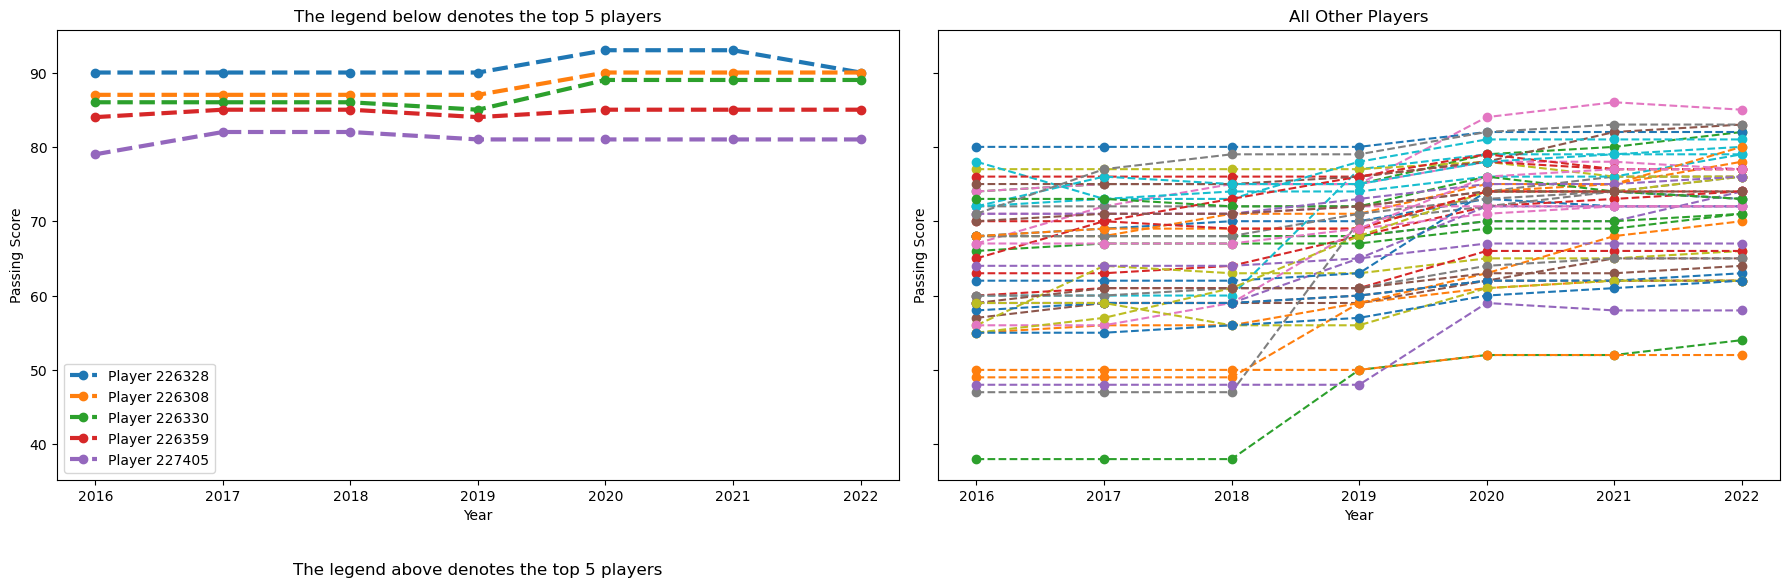

In [ ]:
#This gathers the top 5 players.
top5 = df_passing_sorted["sofifa_id"].head(5).values

#This identifies the remaining players.
all_players = df_long["sofifa_id"].unique()
others = list(set(all_players) - set(top5))

#This creates side-by-side subplots.
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

#Below is the graph for the top 5 players' passing skill over time.
ax = axes[0]
for pid in top5:
    df_player = df_long[df_long["sofifa_id"] == pid]
    ax.plot(df_player["year"], df_player["passing_score"], label=f"Player {pid}", linewidth=3, marker='o', linestyle='--')

ax.set_title("Top 5 Players (Passing Score)", fontsize=16)
ax.set_title("The legend below denotes the top 5 players", fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Passing Score")
ax.legend()

#Below is the graph for the reamaining players' passing skill over time.
ax = axes[1]
for pid in others:
    df_player = df_long[df_long["sofifa_id"] == pid]
    ax.plot(df_player["year"], df_player["passing_score"], marker='o', linestyle='--')

ax.set_title("All Other Players")
ax.set_xlabel("Year")
ax.set_ylabel("Passing Score")


plt.tight_layout()
plt.show()


<font size = 4>
Graph to Show Top 5 Players - Dribbling:

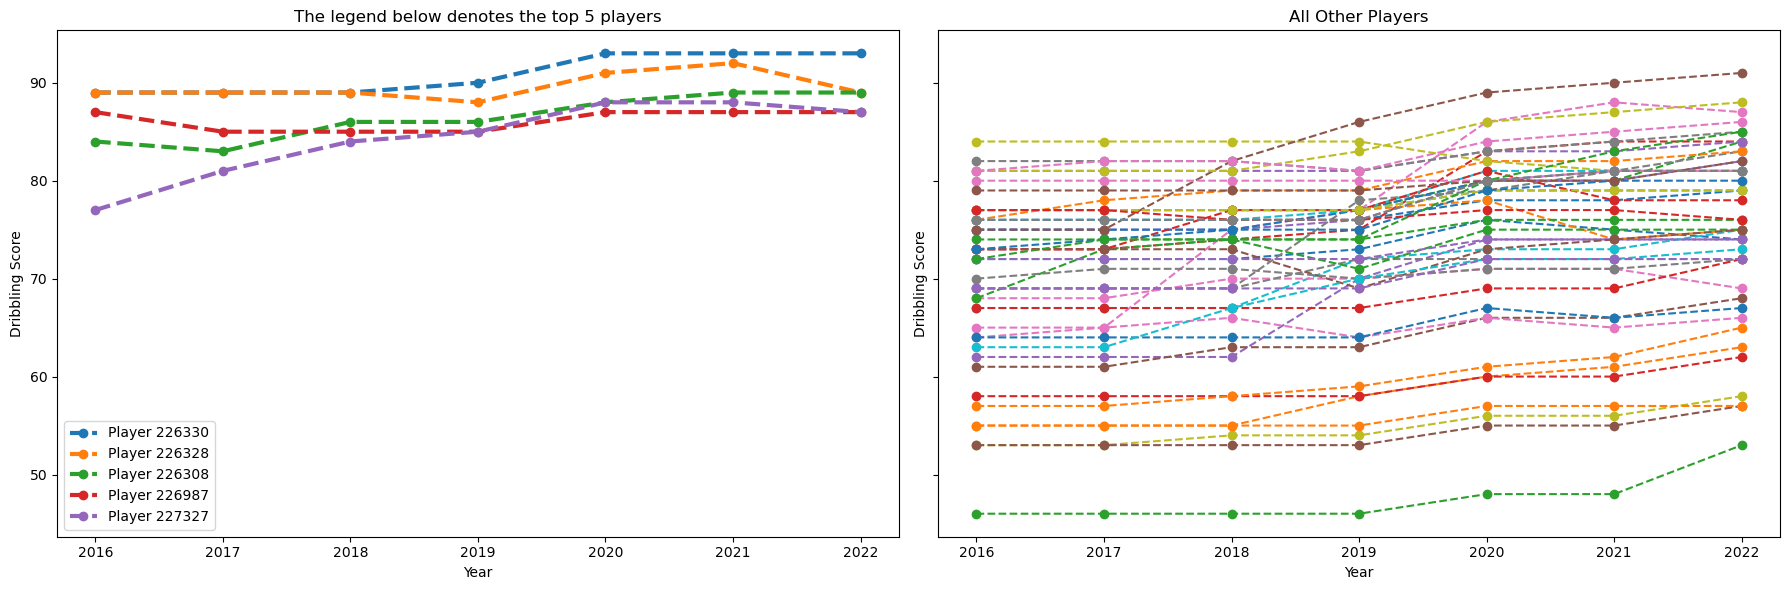

In [9]:
#This gathers the top 5 players.
top5 = df_dribbling_sorted["sofifa_id"].head(5).values

#This identifies the remaining players.
all_players = df_long_dribbling["sofifa_id"].unique()
others = list(set(all_players) - set(top5))

#This creates side-by-side subplots.
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

#Below is the graph for the top 5 players' dribbling skill over time.
ax = axes[0]
for pid in top5:
    df_player = df_long_dribbling[df_long_dribbling["sofifa_id"] == pid]
    ax.plot(df_player["year"], df_player["dribbling_score"], label=f"Player {pid}", linewidth=3, marker='o', linestyle='--')

ax.set_title("Top 5 Players (Highest Mean Dribbling Score)", fontsize=16)
ax.set_title("The legend below denotes the top 5 players", fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Dribbling Score")
ax.legend()

#Below is the graph for the reamaining players' dribbling skill over time.
ax = axes[1]
for pid in others:
    df_player = df_long_dribbling[df_long_dribbling["sofifa_id"] == pid]
    ax.plot(df_player["year"], df_player["dribbling_score"], marker='o', linestyle='--')

ax.set_title("All Other Players")
ax.set_xlabel("Year")
ax.set_ylabel("Dribbling Score")


plt.tight_layout()
plt.show()

<font size = 4>
Graph to Show Top 5 Players - Shooting:

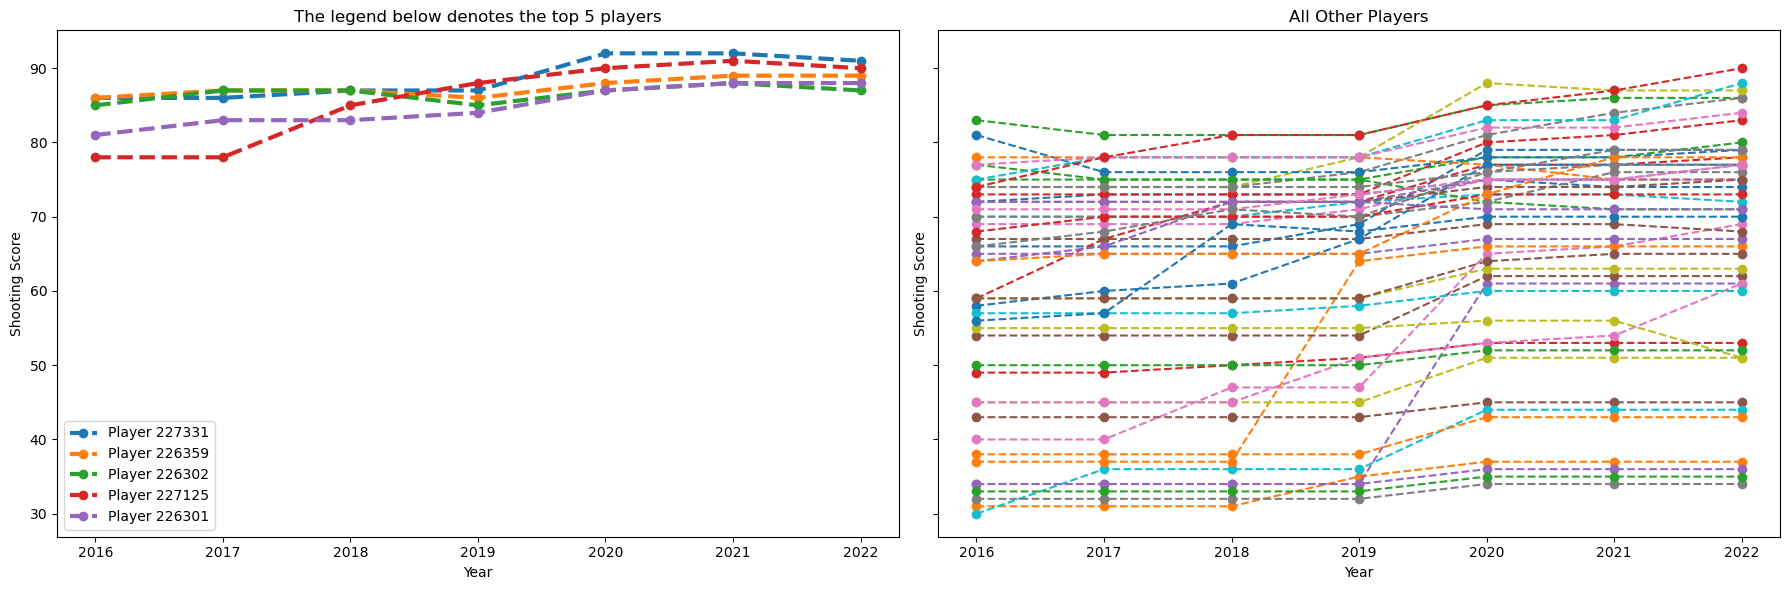

In [10]:
#This gathers the top 5 players.
top5 = df_shooting_sorted["sofifa_id"].head(5).values

#This identifies the remaining players.
all_players = df_long_shooting["sofifa_id"].unique()
others = list(set(all_players) - set(top5))

#This creates side-by-side subplots.
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

#Below is the graph for the top 5 players' shooting skill over time.
ax = axes[0]
for pid in top5:
    df_player = df_long_shooting[df_long_shooting["sofifa_id"] == pid]
    ax.plot(df_player["year"], df_player["shooting_score"], label=f"Player {pid}", linewidth=3, marker='o', linestyle='--')

ax.set_title("Top 5 Players (Highest Mean Shooting Score)", fontsize=16)
ax.set_title("The legend below denotes the top 5 players", fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Shooting Score")
ax.legend() 

#Below is the graph for the reamaining players' shooting skill over time.
ax = axes[1]
for pid in others:
    df_player = df_long_shooting[df_long_shooting["sofifa_id"] == pid]
    ax.plot(df_player["year"], df_player["shooting_score"], marker='o', linestyle='--')

ax.set_title("All Other Players")
ax.set_xlabel("Year")
ax.set_ylabel("Shooting Score")

plt.tight_layout()
plt.show()

<font size = 4>
Progress Made on Passing Skills from 2016 to 2022:

In [11]:
#This computes progress made on passing skill from 2016 to 2022.
start = "passing_16"
end = "passing_22"
df_merged["overall_change_passing"] = df_merged[end] - df_merged[start]

#This fills na values with zeroes.
df_merged["overall_change_passing"] = df_merged["overall_change_passing"].fillna(0)

df_progress_passing = df_merged[       ["sofifa_id", start, end, "overall_change_passing"]      ].sort_values(by="overall_change_passing", ascending=False)


#This computes progress made on dribbling skill from 2016 to 2022.
start_dribbling = "dribbling_16"
end_dribbling = "dribbling_22"
df_merged["overall_change_dribbling"] = df_merged[end_dribbling] - df_merged[start_dribbling]

#This fills na values with zeroes.
df_merged["overall_change_dribbling"] = df_merged["overall_change_dribbling"].fillna(0)

df_progress_dribbling = df_merged[       ["sofifa_id", start_dribbling, end_dribbling, "overall_change_dribbling"]      ].sort_values(by="overall_change_dribbling", ascending=False)


#This computes progress made on shooting skill from 2016 to 2022.
start_shooting = "shooting_16"
end_shooting = "shooting_22"
df_merged["overall_change_shooting"] = df_merged[end_shooting] - df_merged[start_shooting]

#This fills na values with zeroes.
df_merged["overall_change_shooting"] = df_merged["overall_change_shooting"].fillna(0)

df_progress_shooting = df_merged[       ["sofifa_id", start_shooting, end_shooting, "overall_change_shooting"]      ].sort_values(by="overall_change_shooting", ascending=False)

display(df_progress_passing)
display(df_progress_dribbling)
display(df_progress_shooting)



,sofifa_id,passing_16,passing_22,overall_change_passing
51,226327,47.0,76.0,29.0
48,227255,55.0,76.0,21.0
13,226333,60.0,80.0,20.0
50,227350,67.0,85.0,18.0
52,226979,38.0,54.0,16.0
...,...,...,...,...
19,226331,NaN,NaN,0.0
15,227313,NaN,NaN,0.0
8,227400,NaN,NaN,0.0
63,227925,NaN,NaN,0.0


,sofifa_id,dribbling_16,dribbling_22,overall_change_dribbling
50,227350,64.0,87.0,23.0
24,227125,75.0,91.0,16.0
51,226327,69.0,83.0,14.0
34,227192,72.0,85.0,13.0
59,227466,62.0,74.0,12.0
...,...,...,...,...
8,227400,NaN,NaN,0.0
63,227925,NaN,NaN,0.0
35,227193,77.0,76.0,-1.0
28,227116,77.0,75.0,-2.0


,sofifa_id,shooting_16,shooting_22,overall_change_shooting
50,227350,40.0,69.0,29.0
13,226333,37.0,66.0,29.0
59,227466,34.0,61.0,27.0
55,227361,59.0,78.0,19.0
36,227257,58.0,77.0,19.0
...,...,...,...,...
35,227193,72.0,71.0,-1.0
11,226987,81.0,79.0,-2.0
28,227116,78.0,75.0,-3.0
14,227115,75.0,71.0,-4.0


<font size = 4>
Combined Skills Overall Change Table (values sorted highest to lowest by passing score):

In [12]:
#This computes the overall progress made across passing, dribbling, and shooting over time.
df_skill_changes = df_merged[[
    "sofifa_id",
    "overall_change_passing",
    "overall_change_shooting",
    "overall_change_dribbling"
]].sort_values("overall_change_passing", ascending=False).reset_index(drop=True)

display(df_skill_changes)


,sofifa_id,overall_change_passing,overall_change_shooting,overall_change_dribbling
0,226327,29.0,12.0,14.0
1,227255,21.0,13.0,7.0
2,226333,20.0,29.0,8.0
3,227350,18.0,29.0,23.0
4,226979,16.0,2.0,7.0
...,...,...,...,...
59,226331,0.0,0.0,0.0
60,227313,0.0,0.0,0.0
61,227400,0.0,0.0,0.0
62,227925,0.0,0.0,0.0


<font size = 4>
Combined Skills Overall Change Bar Graph (values sorted highest to lowest):

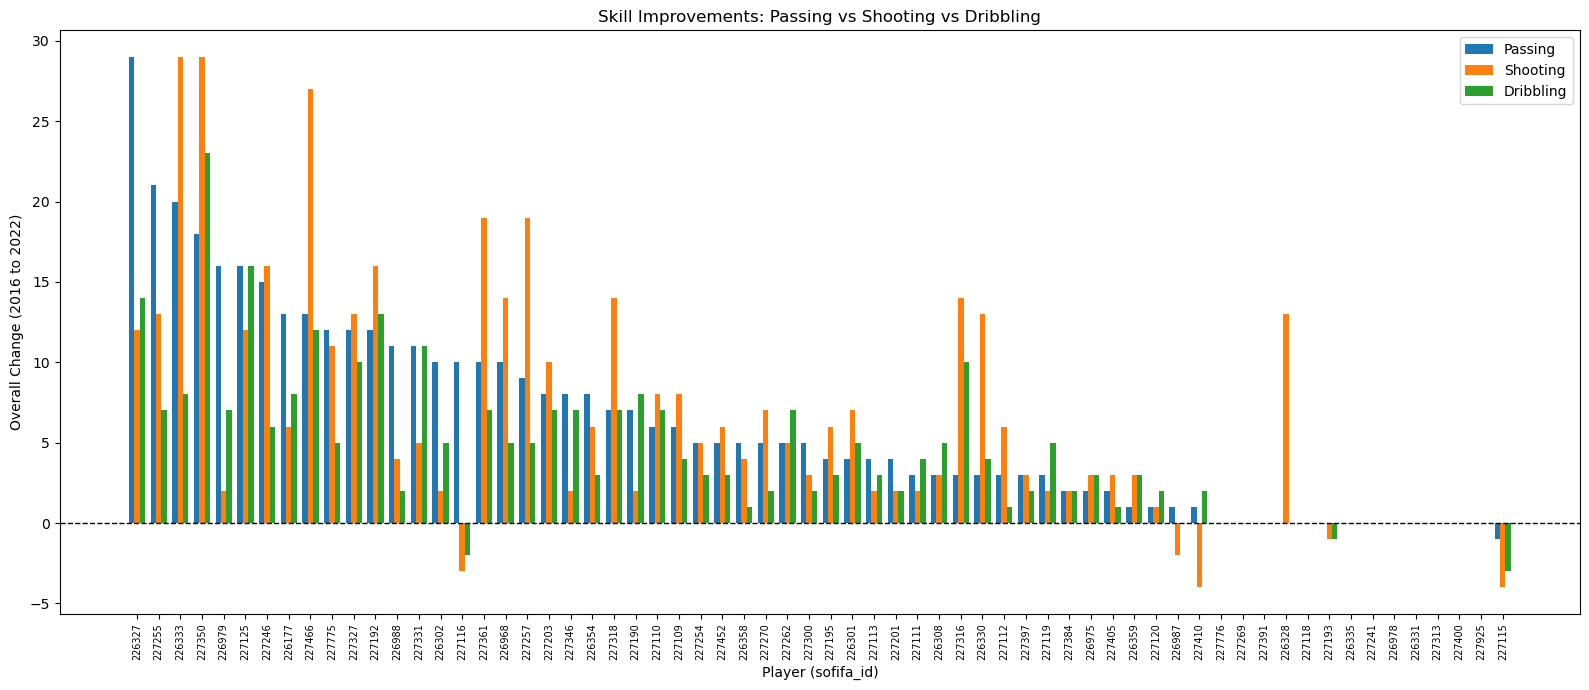

In [13]:
#Here we make a graph showing overall skill progress for all players.

# This specifies X positions.
x = np.arange(len(df_skill_changes))  

width = 0.25  # width of each bar

plt.figure(figsize=(16,7))

# This creates three bar types differentiated by color, one for each skill (passing, dribbling, and shooting) with adequate spacing.
plt.bar(x - width, df_skill_changes["overall_change_passing"], width, label="Passing")
plt.bar(x,         df_skill_changes["overall_change_shooting"], width, label="Shooting")
plt.bar(x + width, df_skill_changes["overall_change_dribbling"], width, label="Dribbling")

# This adds labels to our plot.
plt.xticks(x, df_skill_changes["sofifa_id"].astype(str), rotation=90, fontsize=7)
plt.ylabel("Overall Change (2016 to 2022)")
plt.xlabel("Player (sofifa_id)")
plt.title("Skill Improvements: Passing vs Shooting vs Dribbling")
plt.legend()

plt.tight_layout()
plt.axhline(y=0, color="black", linestyle="--", linewidth=1)
plt.show()


<font size = 4>
Individual Skills Change Over Time Bar Graph (values sorted highest to lowest):

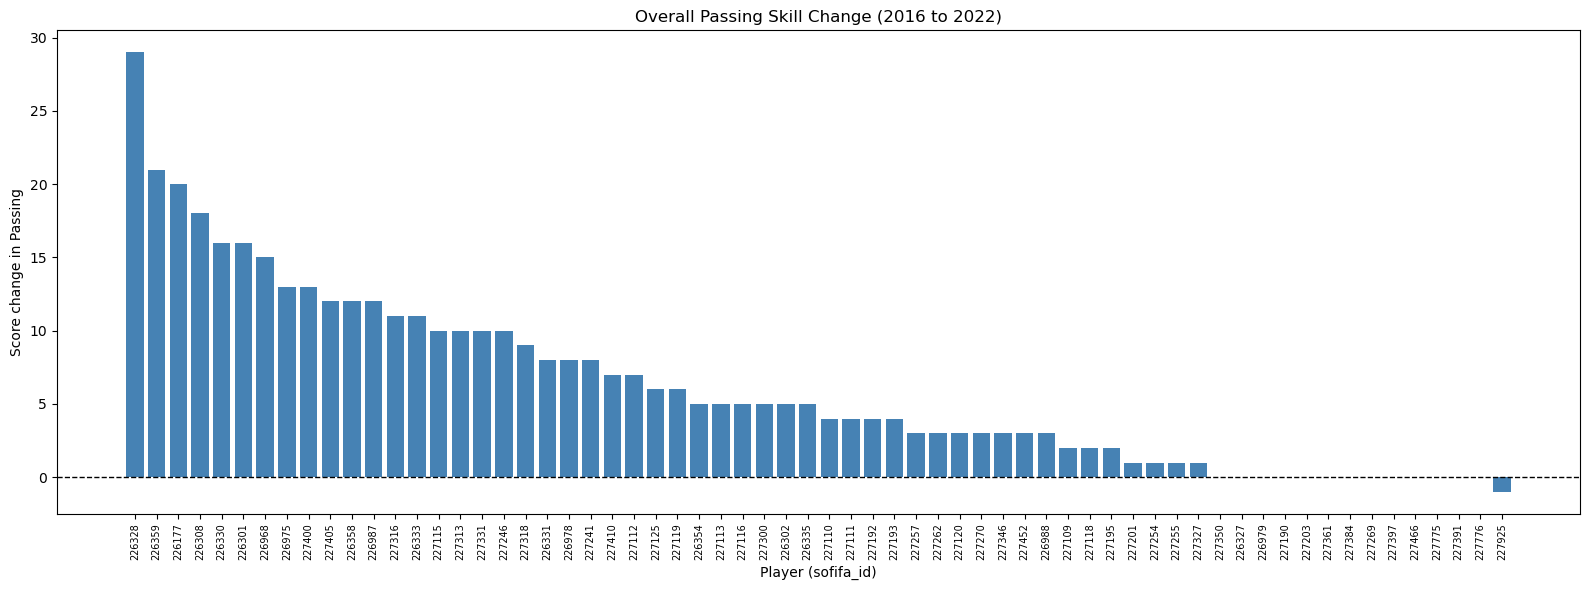

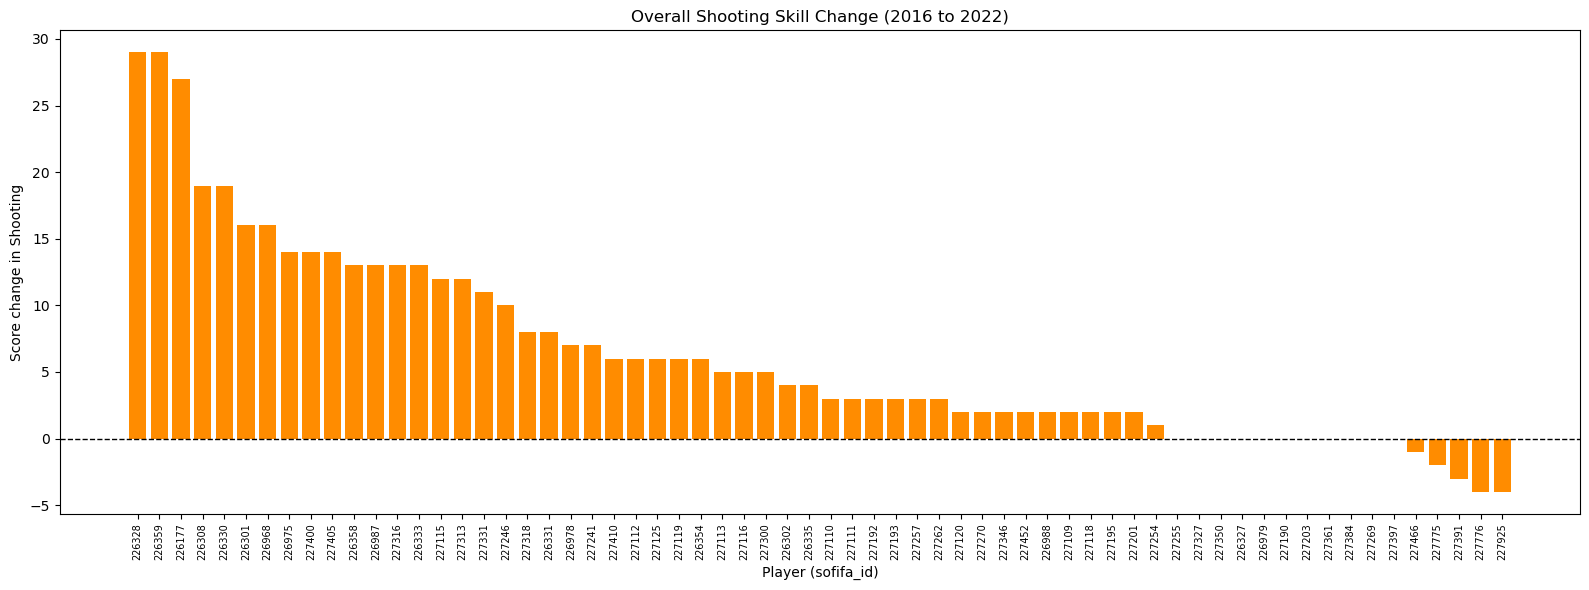

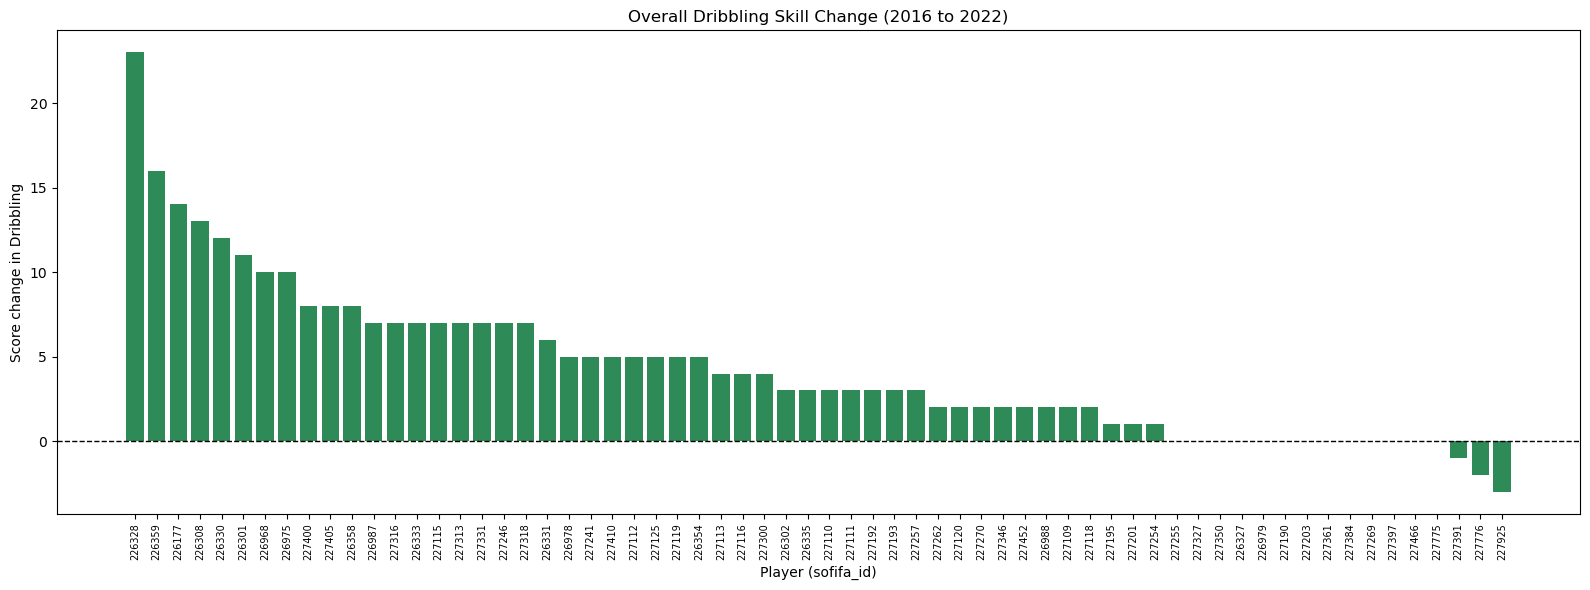

In [14]:
x_labels = df_merged["sofifa_id"].astype(str)
x = np.arange(len(df_merged))

#This graphs passing progress over time.
plt.figure(figsize=(16,6))
plt.bar(x, df_progress_passing["overall_change_passing"], color="steelblue")
plt.xticks(x, x_labels, rotation=90, fontsize=7)
plt.title("Overall Passing Skill Change (2016 to 2022)")
plt.xlabel("Player (sofifa_id)")
plt.ylabel("Score change in Passing")
plt.tight_layout()
plt.axhline(y=0, color="black", linestyle="--", linewidth=1)
plt.show()


#This graphs shooting progress over time.
plt.figure(figsize=(16,6))
plt.bar(x, df_progress_shooting["overall_change_shooting"], color="darkorange")
plt.xticks(x, x_labels, rotation=90, fontsize=7)
plt.title("Overall Shooting Skill Change (2016 to 2022)")
plt.xlabel("Player (sofifa_id)")
plt.ylabel("Score change in Shooting")
plt.tight_layout()
plt.axhline(y=0, color="black", linestyle="--", linewidth=1)
plt.show()


#This graphs dribbling progress over time.
plt.figure(figsize=(16,6))
plt.bar(x, df_progress_dribbling["overall_change_dribbling"], color="seagreen")
plt.xticks(x, x_labels, rotation=90, fontsize=7)
plt.title("Overall Dribbling Skill Change (2016 to 2022)")
plt.xlabel("Player (sofifa_id)")
plt.ylabel("Score change in Dribbling")
plt.tight_layout()
plt.axhline(y=0, color="black", linestyle="--", linewidth=1)
plt.show()

# <span style="color:red"> <font size = 5> Conclusions: </span>
<font size = 3>
The line graphs show that players with higher initial scores in passing, dribbling, and shooting generally show less improvement than players with lower initial scores in those technical skills, demonstrating a slight upwards trend with a plateau. However, generally, most players had positive improvement in their scores, with there being far more variation in the non-top 5 player group. This is reinforced by the Individual Skills Change Over Time Bar Graph, as only a few players had a negative overall change in score (1 for passing, 5 for shooting, and 3 for dribbling). Looking at the Combined Skills Overall Change Bar Graph, the technical skills that generally had the most improvement over time, were shooting, followed by passing, and lastly followed by dribbling. 
In terms of individual improvement, the player with sofifa_id 226327 had the highest overall passing score improvement (increased by 29 points); the player with sofifa_id 227350 had the highester overall dribbling score improvement (increased by 23 points); the players with sofifa_ids 227350 226333 had the highest overall shooting score improvement (increased by 29 points each).

# <span style="color:red"> (2) Which countries tend to produce players with the highest ratings in passing, dribbling, and shooing skills? </span>

# <span style="color:red"> <font size = 5> Merging Procedure: </span>

<font size = 3>

We used the same original merged dataframe from the first research question and then extracted the sofifa_id, nationality_name and nationality_id columns for each year. We then merged those columns with the passing, dribbling, and shooting score datasets generated above with left joins to generate three datasets for analysis.

# <span style="color:red"> <font size = 5> Cleaning Procedure: </span>

<font size = 3>

Again, to make the data easier to visualize graphically, we melted the dataframe into long form. The mean columns for passing, dribbling, and shooting skills calculated from research question 1 were important for this analysis, so we kept it in the long dataframe. We then grouped the players by nationality, aggregated the data to calculate average passing, dribbling, and shooting skills among all players by country over 2016 to 2022, and aggregated the data to calculate standard deviation for that calcuation. We used the .dropna() function to ensure there are no missing values for the passing, dribbling, and shooting skills columns we are interested in. Additionally, the passing, dribbling, and shooting columns were the correct datatype needed, float64, to visualize them graphically.

# <span style="color:red"> <font size = 5> Description of Main Columns: </span>

<font size = 3>

The main columns analyzed include sofifa_id, nationality, and the mean passing, dribbling, and shooting score columns from 2016 to 2022. The sofifa_id column contains unique IDs for each soccer player. The nationality column indicates which country a player is from. The mean passing, dribbling, and shooting score columns contain scores representing the average of every player's average scores for each respective technical skill. A higher score means a player is better at that certain skill. A descriptive table showing the number of times each country is represented by the players analyzed was calculated and is shown below. 



In [15]:
#This renames the passing column without a number to passing_16.
df_merged = df_merged.rename(columns={"nationality_id": "nationality_id_16"})
df_merged = df_merged.rename(columns={"nationality_name": "nationality_name_16"})

#This gathers their passing skill for year 2016 to 2022
nationality_id_cols = [f"nationality_id_{y}" for y in years]
print(nationality_id_cols)

nationality_name_cols = [f"nationality_name_{y}" for y in years]
print(nationality_name_cols)


#This creates a new dataframe with only sofifa_id and passing skills as columns.
df_nationality = df_merged[["sofifa_id"] + nationality_name_cols + nationality_id_cols]
df_nationality = df_nationality.dropna()


df_nationality


['nationality_id_16', 'nationality_id_17', 'nationality_id_18', 'nationality_id_19', 'nationality_id_20', 'nationality_id_21', 'nationality_id_22']
['nationality_name_16', 'nationality_name_17', 'nationality_name_18', 'nationality_name_19', 'nationality_name_20', 'nationality_name_21', 'nationality_name_22']


,sofifa_id,nationality_name_16,nationality_name_17,nationality_name_18,nationality_name_19,nationality_name_20,nationality_name_21,nationality_name_22,nationality_id_16,nationality_id_17,nationality_id_18,nationality_id_19,nationality_id_20,nationality_id_21,nationality_id_22
0,226328,United States,United States,United States,United States,United States,United States,United States,95,95,95,95,95,95,95
1,226359,Canada,Canada,Canada,Canada,Canada,Canada,Canada,70,70,70,70,70,70,70
2,226177,United States,United States,United States,United States,United States,United States,United States,95,95,95,95,95,95,95
3,226308,Germany,Germany,Germany,Germany,Germany,Germany,Germany,21,21,21,21,21,21,21
4,226330,United States,United States,United States,United States,United States,United States,United States,95,95,95,95,95,95,95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,227466,Mexico,Mexico,Mexico,Mexico,Mexico,Mexico,Mexico,83,83,83,83,83,83,83
60,227775,Spain,Spain,Spain,Spain,Spain,Spain,Spain,45,45,45,45,45,45,45
61,227391,Canada,Canada,Canada,Canada,Canada,Canada,Canada,70,70,70,70,70,70,70
62,227776,Spain,Spain,Spain,Spain,Spain,Spain,Spain,45,45,45,45,45,45,45


<font size = 3>
Descriptive Table Finding the Unique Nationality Counts among Players: 

In [16]:
#This finds all the unique nationalities in df_nationality.
unique_nationalities = set()
for col in nationality_name_cols:
    unique_nationalities.update(df_nationality[col].unique())
print(unique_nationalities)


unique_nationalities = ['Mexico', 'France', 'England', 'Spain', 'Germany', 'United States', 'Australia', 'Sweden', 'Canada']


nationality_summary = {}

for nation in unique_nationalities:
    #This find all players from a given nation in any year.
    mask = False
    for col in nationality_name_cols:     # ['nationality_name_16', ..., 'nationality_name_22']
        mask = mask | (df_nationality[col] == nation)     #the meaning of | is "or" operation for boolean masks

    #This filters unique players from a given nation.
    players = df_nationality[mask]["sofifa_id"].unique()

    nationality_summary[nation] = {
        "count": len(players)
    }



#This converts our data into dataframe for ease.
nationality_summary_df = pd.DataFrame.from_dict(nationality_summary, orient='index').reset_index()
nationality_summary_df.columns = ['Nationality', 'Count']
display(nationality_summary_df)





{'Canada', 'Sweden', 'France', 'England', 'Mexico', 'Germany', 'United States', 'Australia', 'Spain'}


,Nationality,Count
0,Mexico,2
1,France,7
2,England,9
3,Spain,8
4,Germany,5
5,United States,8
6,Australia,12
7,Sweden,6
8,Canada,7


<font size = 3>
Merged Passing Score Dataset with Nationalities of Players by sofifa_id and Melted Dataset into Long Form:

In [17]:
display(df_passing_sorted)
#This merges df_passing_sorted with df_nationality on sofifa_id.
df_nationality_passing = df_passing_sorted.merge(
    df_nationality,
    on='sofifa_id',
    how='left'
)


display(df_nationality_passing)

#This converts df_nationality_passing from wide to long format. 
df_nationality_long = df_nationality_passing.melt(
    id_vars=["sofifa_id", "mean_passing"],
    value_vars=nationality_name_cols,
    var_name="year",
    value_name="nationality"
)

display(df_nationality_long)


#This identifies unique nationalities, and adds a column for those identified observations.
unique_nationalities = df_nationality_long["nationality"].unique()


,sofifa_id,passing_16,passing_17,passing_18,passing_19,passing_20,passing_21,passing_22,mean_passing
0,226328,90.0,90.0,90.0,90.0,93.0,93.0,90.0,90.857143
3,226308,87.0,87.0,87.0,87.0,90.0,90.0,90.0,88.285714
4,226330,86.0,86.0,86.0,85.0,89.0,89.0,89.0,87.142857
1,226359,84.0,85.0,85.0,84.0,85.0,85.0,85.0,84.714286
9,227405,79.0,82.0,82.0,81.0,81.0,81.0,81.0,81.000000
7,226975,80.0,80.0,80.0,80.0,82.0,82.0,82.0,80.857143
49,227327,71.0,77.0,79.0,79.0,82.0,83.0,83.0,79.142857
50,227350,67.0,72.0,75.0,75.0,84.0,86.0,85.0,77.714286
26,226354,75.0,75.0,75.0,76.0,78.0,82.0,83.0,77.714286
54,227203,74.0,75.0,75.0,75.0,79.0,80.0,82.0,77.142857


,sofifa_id,passing_16,passing_17,passing_18,passing_19,passing_20,passing_21,passing_22,mean_passing,nationality_name_16,...,nationality_name_20,nationality_name_21,nationality_name_22,nationality_id_16,nationality_id_17,nationality_id_18,nationality_id_19,nationality_id_20,nationality_id_21,nationality_id_22
0,226328,90.0,90.0,90.0,90.0,93.0,93.0,90.0,90.857143,United States,...,United States,United States,United States,95,95,95,95,95,95,95
1,226308,87.0,87.0,87.0,87.0,90.0,90.0,90.0,88.285714,Germany,...,Germany,Germany,Germany,21,21,21,21,21,21,21
2,226330,86.0,86.0,86.0,85.0,89.0,89.0,89.0,87.142857,United States,...,United States,United States,United States,95,95,95,95,95,95,95
3,226359,84.0,85.0,85.0,84.0,85.0,85.0,85.0,84.714286,Canada,...,Canada,Canada,Canada,70,70,70,70,70,70,70
4,227405,79.0,82.0,82.0,81.0,81.0,81.0,81.0,81.000000,Canada,...,Canada,Canada,Canada,70,70,70,70,70,70,70
5,226975,80.0,80.0,80.0,80.0,82.0,82.0,82.0,80.857143,Sweden,...,Sweden,Sweden,Sweden,46,46,46,46,46,46,46
6,227327,71.0,77.0,79.0,79.0,82.0,83.0,83.0,79.142857,Germany,...,Germany,Germany,Germany,21,21,21,21,21,21,21
7,227350,67.0,72.0,75.0,75.0,84.0,86.0,85.0,77.714286,France,...,France,France,France,18,18,18,18,18,18,18
8,226354,75.0,75.0,75.0,76.0,78.0,82.0,83.0,77.714286,Germany,...,Germany,Germany,Germany,21,21,21,21,21,21,21
9,227203,74.0,75.0,75.0,75.0,79.0,80.0,82.0,77.142857,Spain,...,Spain,Spain,Spain,45,45,45,45,45,45,45


,sofifa_id,mean_passing,year,nationality
0,226328,90.857143,nationality_name_16,United States
1,226308,88.285714,nationality_name_16,Germany
2,226330,87.142857,nationality_name_16,United States
3,226359,84.714286,nationality_name_16,Canada
4,227405,81.000000,nationality_name_16,Canada
...,...,...,...,...
366,227190,58.000000,nationality_name_22,Spain
367,226177,55.857143,nationality_name_22,United States
368,227116,52.428571,nationality_name_22,Australia
369,227384,50.857143,nationality_name_22,Canada


# <span style="color:red"> Results: </span>

<font size = 4>
Average Passing Scores by Nationality: 

,nationality,avg_passing,std_passing,count_players
4,Germany,77.457143,7.105904,5
8,United States,73.119048,13.730174,6
6,Spain,70.897959,6.074769,7
1,Canada,70.714286,13.460828,5
5,Mexico,69.285714,5.454824,2
3,France,69.095238,7.761058,6
0,Australia,68.214286,8.039937,10
7,Sweden,66.571429,13.443760,5
2,England,65.265306,5.910574,7


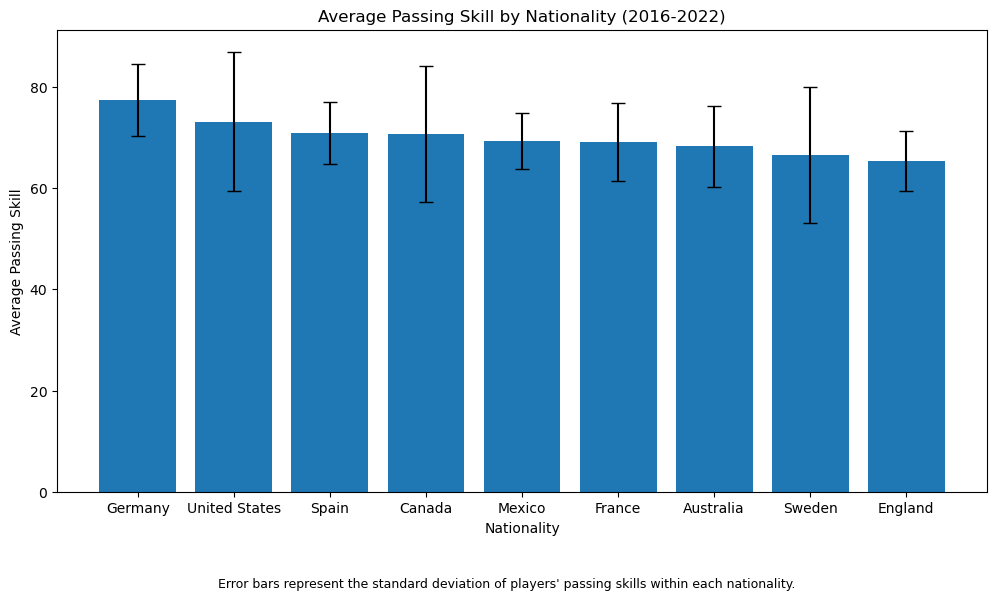

In [18]:
df_country_avg = (
    df_nationality_long[["sofifa_id", "mean_passing", "nationality"]]
    .drop_duplicates(subset=["sofifa_id"])           # This ensures that we only count each player once.
    .groupby("nationality")                          # This groups the observations by nationality.
    .agg(avg_passing=("mean_passing", "mean"),
         std_passing=("mean_passing", "std"),        # This uses .agg to gather the mean, standard deviation, and count.
         count_players=("sofifa_id", "count"))       # This counts the number of players per country. 
    .reset_index()
    .sort_values("avg_passing", ascending=False)     # This sorts the data.
)

display(df_country_avg)

#This adds standard deviation into the bar graph in the form of error bars to see difference in individual players. 
plt.figure(figsize=(12,6))
plt.bar(df_country_avg["nationality"], df_country_avg["avg_passing"], yerr=df_country_avg["std_passing"], capsize=5)
#yerr specifies the error bars, and capsize adds horizontal lines at the top of the error bars.

plt.title("Average Passing Skill by Nationality (2016-2022)")
plt.xlabel("Nationality")
plt.ylabel("Average Passing Skill")

#This creates and specifies error bars on the graph.
plt.figtext(0.5, -0.05, "Error bars represent the standard deviation of players' passing skills within each nationality.", ha="center", fontsize=9)

plt.show()

<font size = 4>
Average Dribbling Skills by Nationality:

,sofifa_id,dribbling_16,dribbling_17,dribbling_18,dribbling_19,dribbling_20,dribbling_21,dribbling_22,mean_dribbling,nationality_name_16,...,nationality_name_20,nationality_name_21,nationality_name_22,nationality_id_16,nationality_id_17,nationality_id_18,nationality_id_19,nationality_id_20,nationality_id_21,nationality_id_22
0,226330,89.0,89.0,89.0,90.0,93.0,93.0,93.0,90.857143,United States,...,United States,United States,United States,95,95,95,95,95,95,95
1,226328,89.0,89.0,89.0,88.0,91.0,92.0,89.0,89.571429,United States,...,United States,United States,United States,95,95,95,95,95,95,95
2,226308,84.0,83.0,86.0,86.0,88.0,89.0,89.0,86.428571,Germany,...,Germany,Germany,Germany,21,21,21,21,21,21,21
3,226987,87.0,85.0,85.0,85.0,87.0,87.0,87.0,86.142857,Sweden,...,Sweden,Sweden,Sweden,46,46,46,46,46,46,46
4,227327,77.0,81.0,84.0,85.0,88.0,88.0,87.0,84.285714,Germany,...,Germany,Germany,Germany,21,21,21,21,21,21,21
5,227125,75.0,75.0,82.0,86.0,89.0,90.0,91.0,84.000000,Australia,...,Australia,Australia,Australia,195,195,195,195,195,195,195
6,227255,81.0,81.0,81.0,83.0,86.0,87.0,88.0,83.857143,England,...,England,England,England,14,14,14,14,14,14,14
7,226301,81.0,82.0,82.0,81.0,84.0,85.0,86.0,83.000000,United States,...,United States,United States,United States,95,95,95,95,95,95,95
8,227115,84.0,84.0,84.0,84.0,82.0,81.0,81.0,82.857143,Australia,...,Australia,Australia,Australia,195,195,195,195,195,195,195
9,226359,82.0,82.0,82.0,81.0,83.0,84.0,85.0,82.714286,Canada,...,Canada,Canada,Canada,70,70,70,70,70,70,70


,sofifa_id,mean_dribbling,year,nationality
0,226330,90.857143,nationality_name_16,United States
1,226328,89.571429,nationality_name_16,United States
2,226308,86.428571,nationality_name_16,Germany
3,226987,86.142857,nationality_name_16,Sweden
4,227327,84.285714,nationality_name_16,Germany
...,...,...,...,...
366,226177,58.142857,nationality_name_22,United States
367,227384,55.857143,nationality_name_22,Canada
368,226968,54.857143,nationality_name_22,Sweden
369,227111,54.142857,nationality_name_22,Australia


,nationality,avg_dribbling,std_dribbling,count_players
4,Germany,81.714286,3.794464,5
8,United States,77.928571,12.492202,6
3,France,74.071429,6.294637,6
5,Mexico,74.000000,8.081220,2
2,England,73.734694,6.898402,7
6,Spain,73.306122,6.584061,7
1,Canada,72.514286,10.544657,5
0,Australia,71.757143,9.577953,10
7,Sweden,68.685714,16.545670,5


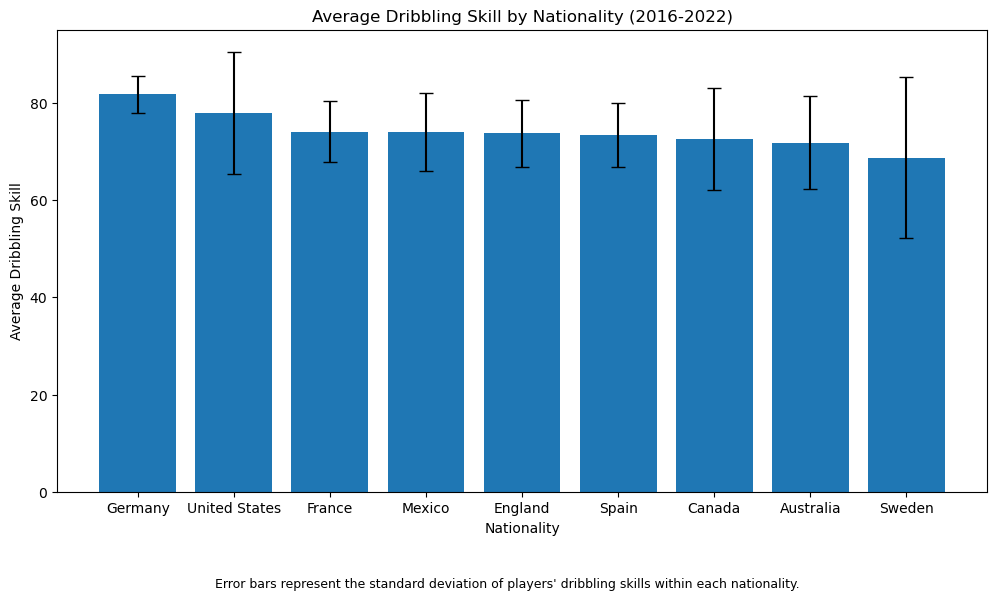

In [19]:
#This merges df_dribbling_sorted with df_nationality on sofifa_id.
df_nationality_dribbling = df_dribbling_sorted.merge(
    df_nationality,
    on='sofifa_id',
    how='left'
)


display(df_nationality_dribbling)

#This converts df_nationality_dribbling from wide to long format.
df_nationality_long_dribbling = df_nationality_dribbling.melt(
    id_vars=["sofifa_id", "mean_dribbling"],
    value_vars=nationality_name_cols,
    var_name="year",
    value_name="nationality"
)

display(df_nationality_long_dribbling)


#This identifies unique nationalities, and adds a column for those identified observations.
unique_nationalities_dribbling = df_nationality_long_dribbling["nationality"].unique()



df_country_avg_dribbling = (
    df_nationality_long_dribbling[["sofifa_id", "mean_dribbling", "nationality"]]
    .drop_duplicates(subset=["sofifa_id"])           # This ensures that we only count each player once.
    .groupby("nationality")                          # This groups the data.
    .agg(avg_dribbling=("mean_dribbling", "mean"),
         std_dribbling=("mean_dribbling", "std"),        # This uses .agg to gather the mean, standard deviation, and count.
         count_players=("sofifa_id", "count"))       # This counts the number of players per country. 
    .reset_index()
    .sort_values("avg_dribbling", ascending=False)     # This sorts the data.
)

display(df_country_avg_dribbling)


plt.figure(figsize=(12,6))
plt.bar(df_country_avg_dribbling["nationality"], df_country_avg_dribbling["avg_dribbling"], yerr=df_country_avg_dribbling["std_dribbling"], capsize=5)
plt.title("Average Dribbling Skill by Nationality (2016-2022)")
plt.xlabel("Nationality")
plt.ylabel("Average Dribbling Skill")

plt.figtext(0.5, -0.05, "Error bars represent the standard deviation of players' dribbling skills within each nationality.", ha="center", fontsize=9)

plt.show()

<font size = 4>
Average Shooting Skills by Nationality:

,sofifa_id,shooting_16,shooting_17,shooting_18,shooting_19,shooting_20,shooting_21,shooting_22,mean_shooting,nationality_name_16,...,nationality_name_20,nationality_name_21,nationality_name_22,nationality_id_16,nationality_id_17,nationality_id_18,nationality_id_19,nationality_id_20,nationality_id_21,nationality_id_22
0,227331,86.0,86.0,87.0,87.0,92.0,92.0,91.0,88.714286,France,...,France,France,France,18,18,18,18,18,18,18
1,226359,86.0,87.0,87.0,86.0,88.0,89.0,89.0,87.428571,Canada,...,Canada,Canada,Canada,70,70,70,70,70,70,70
2,226302,85.0,87.0,87.0,85.0,87.0,88.0,87.0,86.571429,Germany,...,Germany,Germany,Germany,21,21,21,21,21,21,21
3,227125,78.0,78.0,85.0,88.0,90.0,91.0,90.0,85.714286,Australia,...,Australia,Australia,Australia,195,195,195,195,195,195,195
4,226301,81.0,83.0,83.0,84.0,87.0,88.0,88.0,84.857143,United States,...,United States,United States,United States,95,95,95,95,95,95,95
5,226308,83.0,81.0,81.0,81.0,85.0,86.0,86.0,83.285714,Germany,...,Germany,Germany,Germany,21,21,21,21,21,21,21
6,227192,74.0,78.0,81.0,81.0,85.0,87.0,90.0,82.285714,Spain,...,Spain,Spain,Spain,45,45,45,45,45,45,45
7,227255,75.0,78.0,78.0,78.0,83.0,83.0,88.0,80.428571,England,...,England,England,England,14,14,14,14,14,14,14
8,226328,74.0,74.0,74.0,78.0,88.0,87.0,87.0,80.285714,United States,...,United States,United States,United States,95,95,95,95,95,95,95
9,227270,77.0,78.0,78.0,78.0,82.0,82.0,84.0,79.857143,England,...,England,England,England,14,14,14,14,14,14,14


,sofifa_id,mean_shooting,year,nationality
0,227331,88.714286,nationality_name_16,France
1,226359,87.428571,nationality_name_16,Canada
2,226302,86.571429,nationality_name_16,Germany
3,227125,85.714286,nationality_name_16,Australia
4,226301,84.857143,nationality_name_16,United States
...,...,...,...,...
366,226968,38.571429,nationality_name_22,Sweden
367,226979,34.857143,nationality_name_22,Sweden
368,226177,34.142857,nationality_name_22,United States
369,227384,33.857143,nationality_name_22,Canada


,nationality,avg_shooting,std_shooting,count_players
4,Germany,74.600000,11.074608,5
6,Spain,69.632653,10.400110,7
8,United States,67.166667,19.588297,6
3,France,65.523810,15.552850,6
0,Australia,65.114286,15.415309,10
1,Canada,64.828571,20.889261,5
2,England,64.408163,14.981265,7
5,Mexico,59.428571,19.596959,2
7,Sweden,55.828571,20.498482,5


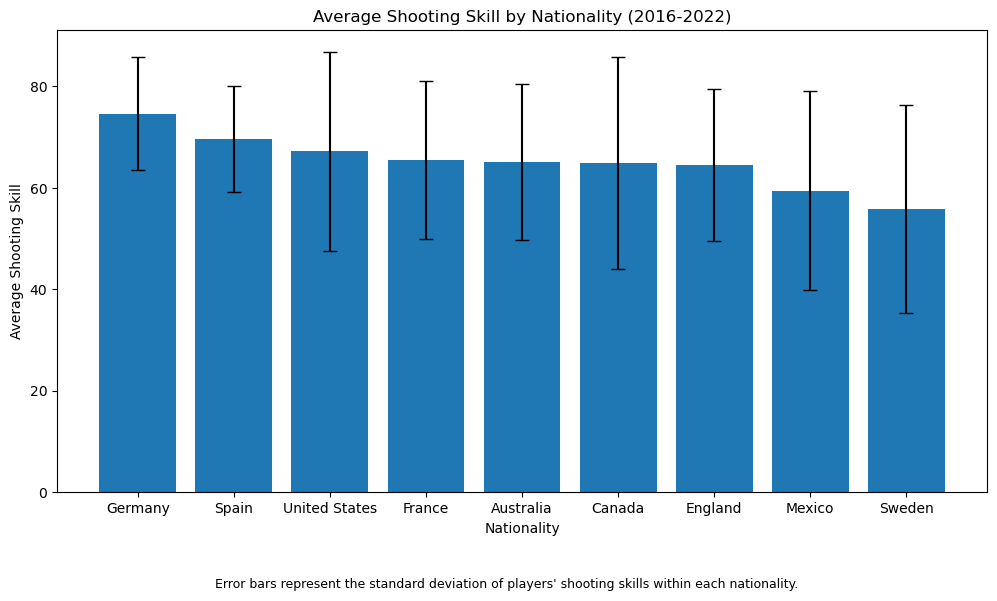

In [20]:

#This merges df_shooting_sorted with df_nationality on sofifa_id.
df_nationality_shooting = df_shooting_sorted.merge(
    df_nationality,
    on='sofifa_id',
    how='left'
)


display(df_nationality_shooting)

#This converts df_nationality_shooting from wide to long format. 
df_nationality_long_shooting = df_nationality_shooting.melt(
    id_vars=["sofifa_id", "mean_shooting"],
    value_vars=nationality_name_cols,
    var_name="year",
    value_name="nationality"
)

display(df_nationality_long_shooting)

#This identifies unique nationalities, and adds a column for those identified observations.
unique_nationalities_shooting = df_nationality_long_shooting["nationality"].unique()



df_country_avg_shooting = (
    df_nationality_long_shooting[["sofifa_id", "mean_shooting", "nationality"]]
    .drop_duplicates(subset=["sofifa_id"])           # This ensures that we only count each player once.
    .groupby("nationality")                          # This groups the data.
    .agg(avg_shooting=("mean_shooting", "mean"),
         std_shooting=("mean_shooting", "std"),        # This uses .agg to gather the mean, standard deviation, and count.
         count_players=("sofifa_id", "count"))       # This counts the number of players per country. 
    .reset_index()
    .sort_values("avg_shooting", ascending=False)     # This sorts the data.
)

display(df_country_avg_shooting)


plt.figure(figsize=(12,6))
plt.bar(df_country_avg_shooting["nationality"], df_country_avg_shooting["avg_shooting"], yerr=df_country_avg_shooting["std_shooting"], capsize=5)
plt.title("Average Shooting Skill by Nationality (2016-2022)")
plt.xlabel("Nationality")
plt.ylabel("Average Shooting Skill")

plt.figtext(0.5, -0.05, "Error bars represent the standard deviation of players' shooting skills within each nationality.", ha="center", fontsize=9)
plt.show()

# <span style="color:red"> <font size = 5> Conclusions: </span>
<font size = 3>
Germany has the highest average scores for all three technical skills analyzed: passing (score of 77.47), dribbling (score of 81.71), and shooting (score of 74.6), with the United States coming in at a close second for passing and dribbling, and Spain coming in second for shooting. England has the lowest average score for passing (score of 65.27), while Sweden had the lowest average scores for dribbling (score of 68.67) and shooting (score of 55.83). Overall, the countries score highest in dribbling skills, followed by passing skills, then shooting.
It's important to note that there was overlap between error bars between every country, suggesting that this result is not statistically significant.


# <span style="color:red"> (3) What is the relationship between a player’s height and their passing, dribbling, and shooting ratings? </span>

# <span style="color:red"> <font size = 5> Merging Procedure: </span>

<font size = 3>

We used the same original merged dataframe from the first research question and then extracted the sofifa_id, and height_cm for each year. We then merged those columns with the passing, dribbling, and shooting score datasets generated from the first research question with inner joins to generate three datasets for analysis.

# <span style="color:red"> <font size = 5> Cleaning Procedure: </span>

<font size = 3>

We calculated the average measured heights of each player over the years from 2016 to 2022 in a new column called mean_height_cm, which was added to the merged dataframe. We then reformatted the mean_height_cm column to meters in a new column called height_in_meters to make it easier to interpret. This new column was in the correct datatype needed to visualize it graphically, int64. We used the .dropna() function to ensure there are no missing values for the passing, dribbling, and shooting skills columns we are interested in. Additionally, the passing, dribbling, and shooting columns were the correct datatype needed, float64, to visualize them graphically.

# <span style="color:red"> <font size = 5> Description of Main Columns: </span>

<font size = 3>

The main columns analyzed include sofifa_id, height_in_meters, mean passing, overall_change_shooting, and overall_change_dribbling. The sofifa_id column contains unique IDs for each soccer player. The mean height columns describe the players' average recorded heights from 2016 to 2022. The mean passing contain scores representing each player's passing score averaged over the years 2016 to 2022. A higher score means a player is better at that certain skill. The overall_change_shooting and overall_change_dribbling columns calculated from the first research question represent the difference between a player's scores in 2022 and a player's scores in 2016. 

<font size = 3>
Get Height Columns from Every Dataset and Calculate the Mean Height Columns:

In [21]:
#This renames the passing column without a number to passing_16.
df_merged = df_merged.rename(columns={"height_cm": "height_cm_16"})

#This gathers their dribbling skill from years 2016 to 2022.
height_cm_cols = [f"height_cm_{y}" for y in years]
print(height_cm_cols)


#This creates a new dataframe with only sofifa_id and dribbling skills as columns. 
df_height_cm = df_merged[["sofifa_id"] + height_cm_cols]
df_height_cm = df_height_cm.dropna()


#This calculates the mean dribbling skill for each observation.
df_height_cm["mean_height_cm"] = df_height_cm[height_cm_cols].mean(axis=1)

#This defines a function to first round values (in cm) to the nearest integer, and then convert them into meters.
def cm_to_meters(cm):
    cm_rounded = round(cm)
    meters = cm_rounded / 100
    return meters

df_height_cm["mean_height_meters"] = df_height_cm["mean_height_cm"].apply(cm_to_meters)

df_height = df_height_cm
display(df_height)

['height_cm_16', 'height_cm_17', 'height_cm_18', 'height_cm_19', 'height_cm_20', 'height_cm_21', 'height_cm_22']


,sofifa_id,height_cm_16,height_cm_17,height_cm_18,height_cm_19,height_cm_20,height_cm_21,height_cm_22,mean_height_cm,mean_height_meters
0,226328,170,170,170,170,170,170,170,170.000000,1.70
1,226359,175,175,175,175,176,176,175,175.285714,1.75
2,226177,170,170,170,170,170,170,170,170.000000,1.70
3,226308,171,173,173,173,171,171,171,171.857143,1.72
4,226330,168,168,168,168,168,168,168,168.000000,1.68
...,...,...,...,...,...,...,...,...,...,...
59,227466,160,160,160,160,160,160,161,160.142857,1.60
60,227775,163,161,161,161,161,161,161,161.285714,1.61
61,227391,178,178,178,178,178,178,178,178.000000,1.78
62,227776,169,169,169,169,169,169,169,169.000000,1.69


<font size = 3>
At first, we attempted to define a function to code for a dichotomous height variable (over versus under a specific height threshold of 1.625 meters), however, we realized that dichotomizing this variable would be inappropriate and reductive, and thus decided to continue with a regression analysis of technical skill scores on height. Nevertheless, our work to dichotomize the height variable is below.

In [22]:
#This defines a function to classify players by height.
def classify_height(meters):
    if meters < 1.625:
        return "short"
    else:
        return "tall"

#This uses .apply to create a new categorical column.
df_height_cm["height_category"] = df_height_cm["mean_height_meters"].apply(classify_height)

display(df_height_cm)

,sofifa_id,height_cm_16,height_cm_17,height_cm_18,height_cm_19,height_cm_20,height_cm_21,height_cm_22,mean_height_cm,mean_height_meters,height_category
0,226328,170,170,170,170,170,170,170,170.000000,1.70,tall
1,226359,175,175,175,175,176,176,175,175.285714,1.75,tall
2,226177,170,170,170,170,170,170,170,170.000000,1.70,tall
3,226308,171,173,173,173,171,171,171,171.857143,1.72,tall
4,226330,168,168,168,168,168,168,168,168.000000,1.68,tall
...,...,...,...,...,...,...,...,...,...,...,...
59,227466,160,160,160,160,160,160,161,160.142857,1.60,short
60,227775,163,161,161,161,161,161,161,161.285714,1.61,short
61,227391,178,178,178,178,178,178,178,178.000000,1.78,tall
62,227776,169,169,169,169,169,169,169,169.000000,1.69,tall


<font size = 3>
Merge Datasets with Mean Passing, Overall_Change_Shooting, and Overall_Change_Dribbling Columns to Prepare for Regression:

In [23]:
# This merges height data with passing data.
df_regression = df_height.merge(
    df_passing_sorted[["sofifa_id", "mean_passing"]],
    on="sofifa_id",
    how="inner"
)

# This merges shooting data.
df_regression = df_regression.merge(
    df_shooting_sorted[["sofifa_id", "mean_shooting"]],
    on="sofifa_id",
    how="inner"
)

# This merges dribbling data.
df_regression = df_regression.merge(
    df_dribbling_sorted[["sofifa_id", "mean_dribbling"]],
    on="sofifa_id",
    how="inner"
)

display(df_regression)

,sofifa_id,height_cm_16,height_cm_17,height_cm_18,height_cm_19,height_cm_20,height_cm_21,height_cm_22,mean_height_cm,mean_height_meters,height_category,mean_passing,mean_shooting,mean_dribbling
0,226328,170,170,170,170,170,170,170,170.000000,1.70,tall,90.857143,80.285714,89.571429
1,226359,175,175,175,175,176,176,175,175.285714,1.75,tall,84.714286,87.428571,82.714286
2,226177,170,170,170,170,170,170,170,170.000000,1.70,tall,55.857143,34.142857,58.142857
3,226308,171,173,173,173,171,171,171,171.857143,1.72,tall,88.285714,83.285714,86.428571
4,226330,168,168,168,168,168,168,168,168.000000,1.68,tall,87.142857,72.000000,90.857143
5,226301,170,170,170,170,170,170,170,170.000000,1.70,tall,72.285714,84.857143,83.000000
6,226968,175,176,176,176,176,176,176,175.857143,1.76,tall,63.142857,38.571429,54.857143
7,226975,173,173,173,173,173,176,176,173.857143,1.74,tall,80.857143,76.857143,77.000000
8,227405,172,172,172,172,172,172,172,172.000000,1.72,tall,81.000000,75.142857,80.285714
9,226358,174,174,174,174,174,174,174,174.000000,1.74,tall,60.428571,60.714286,65.285714


# <span style="color:red"> Results: </span>

Run Regression to Find Relationship Between Player's Height and Mean Passing Scores, Mean Shooting Scores, and Mean Dribbling Scores:

r (height vs passing) = -0.12105035385180388
r (height vs shooting) = -0.033140331348954104
r (height vs dribbling) = -0.2616194577206845


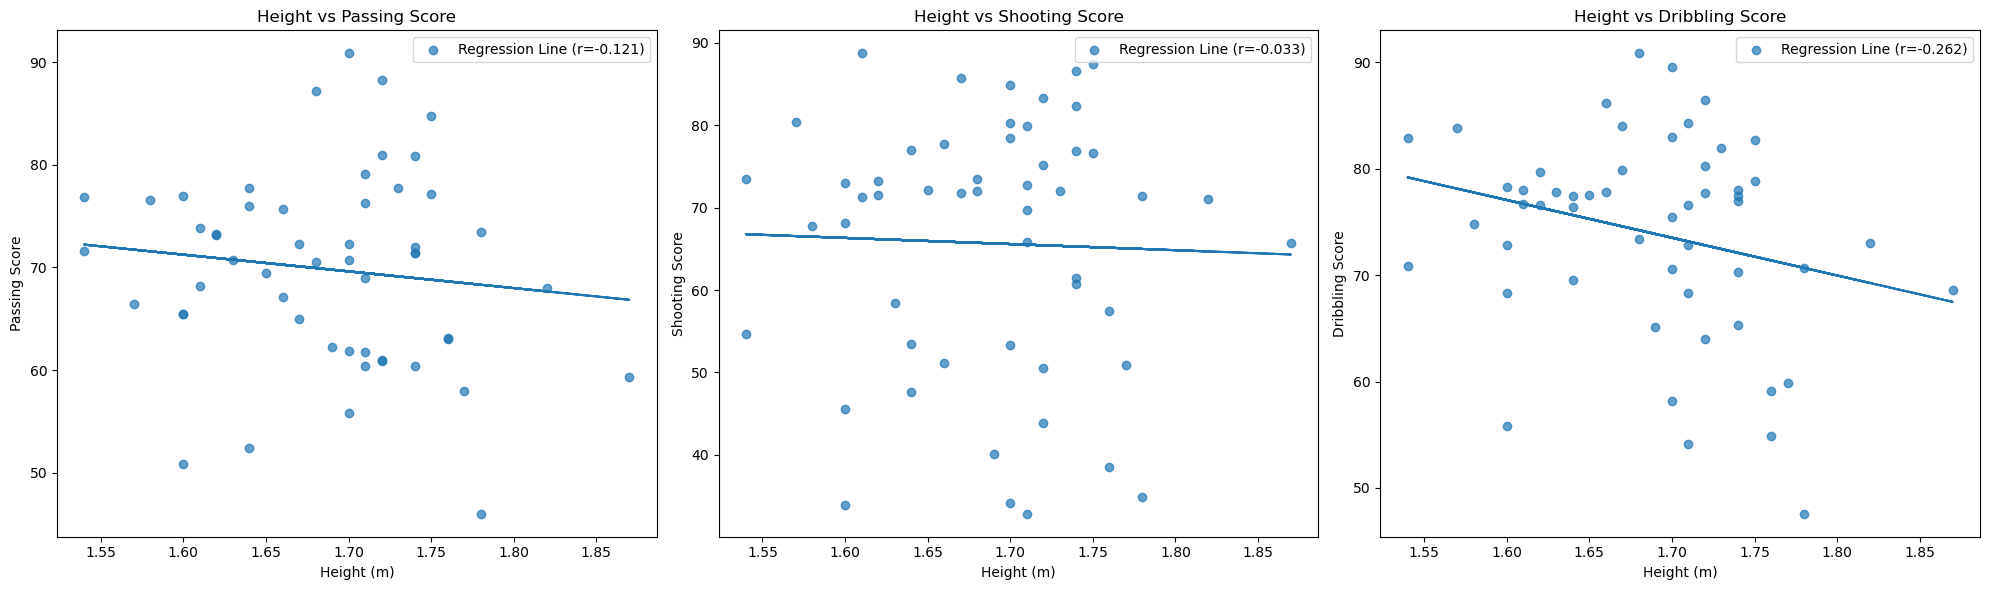

In [24]:
model_pass = smf.ols("mean_passing ~ mean_height_meters", data=df_regression).fit()
model_shoot = smf.ols("mean_shooting ~ mean_height_meters", data=df_regression).fit()
model_drib = smf.ols("mean_dribbling ~ mean_height_meters", data=df_regression).fit()

#This computes predicted values for passing, shooting, and dribbling skill.
df_regression["pred_pass"] = model_pass.predict(df_regression)
df_regression["pred_shoot"] = model_shoot.predict(df_regression)
df_regression["pred_drib"] = model_drib.predict(df_regression)

r_pass = df_regression["mean_height_meters"].corr(df_regression["mean_passing"])
r_shoot = df_regression["mean_height_meters"].corr(df_regression["mean_shooting"])
r_drib = df_regression["mean_height_meters"].corr(df_regression["mean_dribbling"])

print("r (height vs passing) =", r_pass)
print("r (height vs shooting) =", r_shoot)
print("r (height vs dribbling) =", r_drib)

#The plots the regression analyses.
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

#Below is the regression plot for predictors of passing skill.
axes[0].scatter(df_regression["mean_height_meters"],
                df_regression["mean_passing"],
                alpha=0.7)
axes[0].plot(df_regression["mean_height_meters"],
             df_regression["pred_pass"])
axes[0].set_title("Height vs Passing Score")
axes[0].set_xlabel("Height (m)")
axes[0].set_ylabel("Passing Score")
axes[0].legend([f"Regression Line (r={r_pass.round(3)})"])


#Below is the regression plot for predictors of shooting skill.
axes[1].scatter(df_regression["mean_height_meters"],
                df_regression["mean_shooting"],
                alpha=0.7)
axes[1].plot(df_regression["mean_height_meters"],
             df_regression["pred_shoot"])
axes[1].set_title("Height vs Shooting Score")
axes[1].set_xlabel("Height (m)")
axes[1].set_ylabel("Shooting Score")
axes[1].legend([f"Regression Line (r={r_shoot.round(3)})"])

#Below is the regression plot for predictors of dribbling skill.
axes[2].scatter(df_regression["mean_height_meters"],
                df_regression["mean_dribbling"],
                alpha=0.7)
axes[2].plot(df_regression["mean_height_meters"],
             df_regression["pred_drib"])
axes[2].set_title("Height vs Dribbling Score")
axes[2].set_xlabel("Height (m)")
axes[2].set_ylabel("Dribbling Score")
axes[2].legend([f"Regression Line (r={r_drib.round(3)})"])

plt.tight_layout()
plt.show()


# <span style="color:red"> <font size = 5> Conclusions: </span>
<font size = 3>
The scatter plots do not show clear negative or positive trends, and the associated best-fit regression lines for all three plots do not have strong positive or negative slopes. Our correlation coefficients are as follows: for height predicting passingscore , r = -0.121; for height predicting shooting scor, r = -0.033; for height predicting dribbling score, r = -0.262, all of which indicate incredibly weak correlations with no practical significance. Therefore, these plots show that there is no strong correlation between height and average passing score, average shooting score, and average dribbling score.

# <span style="color:red"> Discussion: </span>

# <span style="color:red"> <font size = 5> (1) How have shooting, dribbling, and passing ratings evolved over time? </span>

<font size = 3>

Players with higher initial scores in passing, dribbling, and shooting have less improvement than players with lower initial scores in those technical skills, as evidenced by our side-by-side graphs demonstrating overall improvement amongst the top 5 versus non-top 5 players. However, generally, most players had positive improvement in their scores. This is reinforced by the Individual Skills Change Over Time Bar Graph, as only a few players had a negative overall change in score (1 for passing, 5 for shooting, and 3 for dribbling). Looking at the Combined Skills Overall Change Bar Graph, the technical skills that had the most improvement over time, were shooting, followed by passing, and lastly followed by dribbling. This suggests that shooting and passing are the most important skills in women's FIFA, as players focused the most time improving those two skills -- or, perhaps they are simply the easiest to improve using popular training methods. Interestingly, we observed a general trend of improvement particularly between 2019 and 2020; further analyses may investigate which factors contributed to this spike in improvement across the majority of players during this time period.

# <span style="color:red"> <font size = 5> (2) Which countries tend to produce players with the highest ratings in these key skill categories? </span>

<font size = 3>

As illustrated in the bar graphs, Germany has the highest average scores for passing, dribbling, and shooting. England had the lowest average score for passing, and Sweden had the lowest average scores for dribbling and shooting. Overall, nations scored highest in dribbling (with scores ranging from 81.71 to 68.67), followed by passing (with scores ranging from 77.46 to 65.27), then shooting (with scores ranging from 74.6 to 55.83). This conflicts with the individual player improvement trends, indicating that perhaps there nation-specific factors (ie. training regimes, etc.) that impact skill improvement beyond the individual level. However, it's important to note that there was overlap between error bars between every country, suggesting that this result is not statistically significant. Thus, we cannot draw any definitive conclusions from this data regarding which countries product players with the highest ratings in these technical skills, suggesting that there is no difference in technical ability between players from the countries represented in the dataset.  

# <span style="color:red"> <font size = 5> (3) What is the relationship between a player’s height and their passing, dribbling, and shooting ratings? </span>

<font size = 3>

As illustrated by the scatter plot and the best fit lines, there does not seem to be any correlation between height and players' average passing scores, progress in shooting skills, and progress in dribbling skills. Additionally, this is corroborated by the low correlation coefficients across all regressions, indicating a limited practical significance. Therefore, a player's height does not seem to determine whether or not they are better at a certain skill.



